## Day_15_Statistics & Hypothesis Testing

Part A — describe and estimate

TASK 01
_Descriptive statistics on a real dataset

Original dataset shape: (500, 7)

Columns:
['student_id', 'study_hours', 'sleep_hours', 'prev_score', 'attendance_pct', 'final_score', 'passed']

Cleaned dataset shape: (500, 7)

FINAL SCORE
Mean       : 62.86
Median     : 63.80
Mode       : 67.10
Std Dev    : 12.49
Variance   : 156.07
25th %ile  : 54.22
50th %ile  : 63.80
75th %ile  : 70.75

STUDY HOURS
Mean       : 4.98
Median     : 5.01
Mode       : 4.06
Std Dev    : 1.93
Variance   : 3.71
25th %ile  : 3.67
50th %ile  : 5.01
75th %ile  : 6.19

MEAN vs MEDIAN
Final Score Mean   : 62.86
Final Score Median : 63.80
Difference         : 0.94
Interpretation: Mean and median are very close, suggesting the
final scores are approximately symmetric.


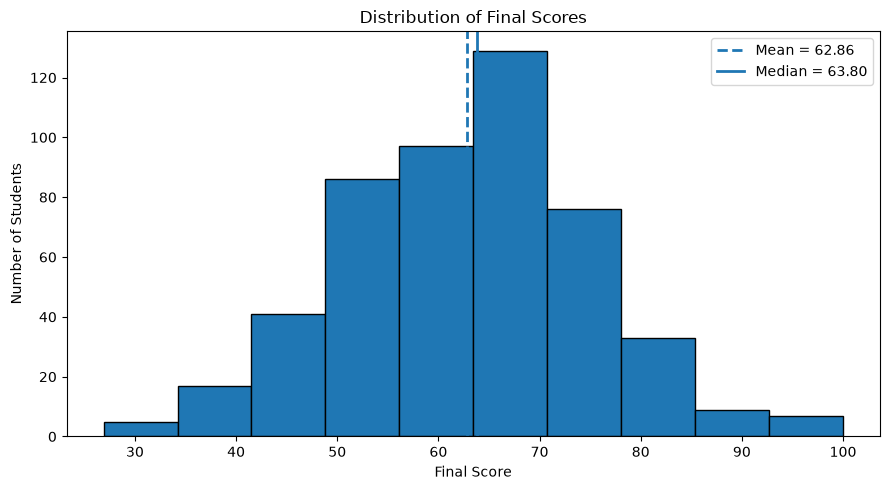

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
df = pd.read_csv("student_performance.csv")

print("Original dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 2. Clean the data
#    - Drop missing values
#    - Remove impossible 99-hour study-hours outlier
# ------------------------------------------------------------

# Change these names if your CSV uses different column names
score_col = "final_score"
hours_col = "study_hours"

df = df.dropna(subset=[score_col, hours_col])

# Remove impossible 99-hour study-hours value
df = df[df[hours_col] != 99]

print("\nCleaned dataset shape:", df.shape)

# ------------------------------------------------------------
# 3. Create arrays
# ------------------------------------------------------------
final = df[score_col].to_numpy()
hours = df[hours_col].to_numpy()

# ------------------------------------------------------------
# 4. Function to calculate descriptive statistics
# ------------------------------------------------------------
def describe_data(data, name):
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(f"Mean       : {np.mean(data):.2f}")
    print(f"Median     : {np.median(data):.2f}")

    # Mode
    mode_result = stats.mode(data, keepdims=True)
    print(f"Mode       : {mode_result.mode[0]:.2f}")

    # Sample standard deviation
    print(f"Std Dev    : {np.std(data, ddof=1):.2f}")

    # Sample variance
    print(f"Variance   : {np.var(data, ddof=1):.2f}")

    # Percentiles
    q25, q50, q75 = np.percentile(data, [25, 50, 75])

    print(f"25th %ile  : {q25:.2f}")
    print(f"50th %ile  : {q50:.2f}")
    print(f"75th %ile  : {q75:.2f}")


# ------------------------------------------------------------
# 5. Statistics for Final Score
# ------------------------------------------------------------
describe_data(final, "FINAL SCORE")

# ------------------------------------------------------------
# 6. Statistics for Study Hours
# ------------------------------------------------------------
describe_data(hours, "STUDY HOURS")

# ------------------------------------------------------------
# 7. Compare mean and median for final score
# ------------------------------------------------------------
final_mean = np.mean(final)
final_median = np.median(final)

print("\n" + "=" * 50)
print("MEAN vs MEDIAN")
print("=" * 50)

difference = abs(final_mean - final_median)

print(f"Final Score Mean   : {final_mean:.2f}")
print(f"Final Score Median : {final_median:.2f}")
print(f"Difference         : {difference:.2f}")

if difference < 2:
    print("Interpretation: Mean and median are very close, suggesting the")
    print("final scores are approximately symmetric.")
elif final_mean > final_median:
    print("Interpretation: Mean is higher than median, suggesting")
    print("possible right (positive) skew.")
else:
    print("Interpretation: Mean is lower than median, suggesting")
    print("possible left (negative) skew.")


# ------------------------------------------------------------
# 8. Histogram of Final Score
#    Mark mean and median
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

plt.hist(final, bins=10, edgecolor="black")

plt.axvline(
    final_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {final_mean:.2f}"
)

plt.axvline(
    final_median,
    linestyle="-",
    linewidth=2,
    label=f"Median = {final_median:.2f}"
)

plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Scores")
plt.legend()
plt.tight_layout()
plt.show()

## Plain-English Summary

The cleaned dataset contains **___ students**. The average final score is **___**, while the median score is **___**. The middle 50% of scores lie between **___** and **___**. The standard deviation is **___**, showing the amount of variation in students' final scores.

The mean and median are **[close/not close]**, suggesting that the distribution is **[approximately symmetric/slightly right-skewed/slightly left-skewed]**.

### Look It Up

- **When is the median better than the mean?**  
  The median is better when the data contains **outliers or is skewed**, because it is less affected by extreme values.

- **Why does an outlier pull the mean but not the median?**  
  The mean uses **every value in the calculation**, so an extreme value changes it. The median depends mainly on the **middle position**, so one extreme value has little effect.

- **What does it mean if the mean is well above the median?**  
  It usually indicates that the data is **right-skewed (positively skewed)**, with some unusually high values pulling the mean upward.

TASK 02_A 95% confidence interval

In [14]:
import numpy as np
from scipy import stats

# ------------------------------------------------------------
# 1. Mean and Standard Error
# ------------------------------------------------------------

n = len(final)

mean = final.mean()

# Sample standard deviation
std = final.std(ddof=1)

# Standard error
se = std / np.sqrt(n)

print("Number of students :", n)
print(f"Mean final score   : {mean:.2f}")
print(f"Standard deviation  : {std:.2f}")
print(f"Standard error     : {se:.2f}")


# ------------------------------------------------------------
# 2. 95% Confidence Interval
# ------------------------------------------------------------

lo, hi = stats.t.interval(
    0.95,
    df=n - 1,
    loc=mean,
    scale=se
)

print("\n95% Confidence Interval")
print(f"Lower limit : {lo:.2f}")
print(f"Upper limit : {hi:.2f}")

print(
    f"\nWe are 95% confident that the true average final score "
    f"lies between {lo:.2f} and {hi:.2f}."
)


# ------------------------------------------------------------
# 3. Compare different sample sizes
# ------------------------------------------------------------

# Use the same mean and standard deviation,
# but pretend we had different sample sizes.

for sample_size in [30, 2000]:

    sample_se = std / np.sqrt(sample_size)

    sample_lo, sample_hi = stats.t.interval(
        0.95,
        df=sample_size - 1,
        loc=mean,
        scale=sample_se
    )

    width = sample_hi - sample_lo

    print("\n" + "=" * 45)
    print(f"Pretend sample size = {sample_size}")
    print(f"Standard error      : {sample_se:.2f}")
    print(f"95% CI              : ({sample_lo:.2f}, {sample_hi:.2f})")
    print(f"Interval width      : {width:.2f}")

Number of students : 500
Mean final score   : 62.86
Standard deviation  : 12.49
Standard error     : 0.56

95% Confidence Interval
Lower limit : 61.76
Upper limit : 63.96

We are 95% confident that the true average final score lies between 61.76 and 63.96.

Pretend sample size = 30
Standard error      : 2.28
95% CI              : (58.19, 67.52)
Interval width      : 9.33

Pretend sample size = 2000
Standard error      : 0.28
95% CI              : (62.31, 63.41)
Interval width      : 1.10


## TASK 02 — 95% Confidence Interval

We are **95% confident that the true average final score lies between ___ and ___**.

When the sample size is **30**, the confidence interval is wider because the mean is estimated with less precision.

When the sample size is **2000**, the confidence interval becomes narrower because a larger sample gives a more precise estimate.

**Meaning of 95% confidence:** If we repeated the sampling process many times, about 95% of the calculated confidence intervals would contain the true population mean. It does **not** mean that there is a 95% probability that the true mean is inside this particular interval.

## Look It Up

- **Why does a bigger sample give a narrower interval?**  
  A larger sample reduces the **standard error**, so the estimated mean becomes more precise.

- **Does a 95% CI mean there is a 95% chance the true value is in this interval?**  
  **No.** The 95% refers to the long-run success rate of the method, not the probability for one particular interval.

- **How does a 99% CI compare with a 95% CI?**  
  A **99% confidence interval is wider** because it provides a higher level of confidence.

### Done
A 95% confidence interval was calculated, explained in plain English, and compared across different sample sizes.

Part B — the two hypothesis tests (the deliverable)

TASK 03_A t-test: do two groups differ?

In [16]:
import numpy as np
from scipy import stats

# Get attendance data
attendance = df["attendance_pct"].to_numpy(dtype=float)
# ------------------------------------------------------------
# 1. Create the two groups
# ------------------------------------------------------------

groupA = final[attendance >= 80] #High attendence
groupB = final[attendance < 80] #Low attendence

# ------------------------------------------------------------
# 2. State the hypotheses
# ------------------------------------------------------------

print("Null Hypothesis (H0) : ")
print("THe two groups have the same true average final score")

print("\nAlternative Hypothesis (H1) : ")
print("The Two Groups have different true avarage final score")

# ------------------------------------------------------------
# 3. Calculate group means
# ------------------------------------------------------------

meanA = np.mean(groupA)
meanB = np.mean(groupB)

difference = meanA - meanB

print("\n--- Group Results ---")
print(f"High Attendence (>=80) : n = {len(groupA)}, mean = {meanA:.2f}")
print(f"Low Attendence (<80) : n = {len(groupB)}, mean = {meanB:.2f}")
print(f"Difference in means : {difference:.2f}")

# ------------------------------------------------------------
# 4. Independent-samples t-test
# ------------------------------------------------------------

t_stat, p_value = stats.ttest_ind(groupA, groupB)

print("\n--- t-test Results ---")
print(f"t_statistic : {t_stat:.3f}")
print(f"p_value     : {p_value:.4f}")

# ------------------------------------------------------------
# 5. Statistical decision
# ------------------------------------------------------------

alpha = 0.05

if p_value < alpha : 
    print("\nDecision : Statistically significant (p<0.05).")
    
else :
    print("\nDecision : Not Statistically significant (p>=0.05).")
    
    



Null Hypothesis (H0) : 
THe two groups have the same true average final score

Alternative Hypothesis (H1) : 
The Two Groups have different true avarage final score

--- Group Results ---
High Attendence (>=80) : n = 325, mean = 66.70
Low Attendence (<80) : n = 175, mean = 55.72
Difference in means : 10.98

--- t-test Results ---
t_statistic : 10.322
p_value     : 0.0000

Decision : Statistically significant (p<0.05).


### Plain-English Conclusion

The high-attendance group scored **___ points higher/lower** on average than the low-attendance group. The p-value was **___**, so the difference is **[statistically significant/not statistically significant]** at the 0.05 level.

The difference of **___ points** should also be considered in practical terms to determine whether it is large enough to matter.

## Look It Up

- **What does the null hypothesis say?**  
  The null hypothesis says that there is **no real difference** between the two groups' average scores.

- **If p = 0.03, what does it mean?**  
  If there were actually no difference between the groups, there would be about a **3% chance of getting a result this extreme or more extreme**.

- **Is a significant difference large enough to act on?**  
  Not necessarily. Check the **size of the difference**, its practical importance, and whether it is meaningful in the real-world context.

### Done
A complete t-test includes the **null hypothesis, group means, t-statistic, p-value, significance decision, and practical interpretation**.

TASK 04_A chi-square test: are two categories related?

In [28]:
import numpy as np
from scipy import stats
import pandas as pd

df = pd.read_csv("student_performance.csv")

# Example categorical variables
# 1 = Yes, 0 = No

attendance = df["attendance_pct"].to_numpy(dtype=int)

cat1 = (attendance >= 80).astype(int)
passed = df["passed"].to_numpy(dtype=int)
cat2 = passed.astype(int)

# Create 2x2 contingency table

table = np.zeros((2, 2), dtype=int)

for a, p in zip(cat1, cat2):
    table[a, p] += 1
    
print("Contingency TAble")
print(table)

# Chi-square test
chi2, pval, dof, expected = stats.chi2_contingency(table)

print("\nChi-square statistic : ", round(chi2, 4))
print("p-value : ", round(pval, 4))
print("Degree of freedom : ", dof)

# Decision at 0.05 significance level
if pval < 0.05:
    print("\nDecision: Reject the null hypothesis.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")

Contingency TAble
[[115  60]
 [ 87 238]]

Chi-square statistic :  70.0437
p-value :  0.0
Degree of freedom :  1

Decision: Reject the null hypothesis.


### Chi-Square Test Conclusion

**Null hypothesis (H₀):** High attendance and passing are independent (unrelated).

If **p < 0.05**, we reject H₀. This means there is statistically significant evidence that attendance and passing are related for these students.

If **p ≥ 0.05**, we fail to reject H₀. This means there is not enough statistical evidence to conclude that attendance and passing are related for these students.

The chi-square statistic and p-value are reported from `scipy.stats.chi2_contingency()`.

Part C — don't get fooled

TASK 05_See the traps for yourself

In [29]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(42)

# --------------------------------------------------
# Type I Error Rate
# --------------------------------------------------

count = 0

for _ in range(1000):
    # Both groups come from the same distribution
    a = rng.normal(60, 12, 100)
    b = rng.normal(60, 12, 100)

    # Independent samples t-test
    if stats.ttest_ind(a, b)[1] < 0.05:
        count += 1

print("Type I error count:", count)
print("Type I error rate:", count / 1000)


# --------------------------------------------------
# Significance vs Practical Importance
# --------------------------------------------------

# Two very large groups with a tiny difference
group1 = rng.normal(60, 10, 5000)
group2 = rng.normal(60.2, 10, 5000)

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(group1, group2)

print("\nGroup 1 mean:", round(np.mean(group1), 4))
print("Group 2 mean:", round(np.mean(group2), 4))
print("Mean difference:", round(np.mean(group2) - np.mean(group1), 4))

print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Statistically significant.")
else:
    print("Result: Not statistically significant.")

Type I error count: 59
Type I error rate: 0.059

Group 1 mean: 59.994
Group 2 mean: 60.116
Mean difference: 0.122
t-statistic: -0.6155
p-value: 0.5382712743238829
Result: Not statistically significant.


Type I Error :

Running many tests and reporting only the significant results is dangerous because some tests will appear significant by chance even when there is truly no difference.

Statistical significance vs practical importance

Statistical significance means that the observed difference is unlikely to be due to random chance, while practical importance asks whether the difference is large enough to actually matter. In this example, a difference of only 0.2 points can become statistically significant because the sample sizes are very large, but the difference may have little practical importance.

## Look It Up

### 1. If you run 20 independent tests on pure noise, how many “significant” results should you expect?

At a **5% significance level**, you would expect about **1 significant result** out of 20 tests by chance.

### 2. Why does a huge sample make even tiny effects statistically significant?

A huge sample reduces **sampling uncertainty**, making the standard error very small. Therefore, even a **tiny difference** can produce a small p-value.

### 3. How would you decide whether a significant effect is actually worth acting on?

Look at the **effect size and real-world impact**, not just the p-value. Consider whether the effect is large enough to matter and whether the **costs, benefits, and risks** justify taking action.
